<a href="https://colab.research.google.com/github/Emmanuel-Oyewole/bookie-buster/blob/main/Bookie_buster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bookie Buster: A Football Betting Value Predictor

This Jupyter Notebook outlines the development and training of a machine learning model named **Bookie Buster**. The goal of this project is to create an analytical tool that can predict football match outcomes and, more importantly, identify "value bets"—instances where the odds offered by bookmakers have a positive Expected Value (+EV).

The model leverages a comprehensive dataset, including historical match results, team statistics, and a full range of betting odds (opening and closing), to learn patterns and make informed predictions. By comparing its own probability estimations with the bookmakers' implied probabilities, Bookie Buster aims to provide a data-driven edge over the market.

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
file_path = '/content/drive/My Drive/ml_dataset_linear_regression.xlsx'

In [32]:
df = pd.read_excel(file_path)

In [33]:
df.head()

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Is Friendly,Competition Type,League Predictability,Implied Odds,Opening Odds,Closing Odds,EV,beat_closing
0,7.0,9.0,28.0,30.0,84.0,No,League,high,1.94,1.59,1.56,-18.0991,0
1,3.0,2.0,27.0,27.0,99.0,No,League,medium,2.01,1.90,1.79,-5.5130,0
2,2.0,10.0,30.0,30.0,78.0,No,League,medium,2.20,2.21,2.24,0.4666,0
3,6.0,7.0,25.0,25.0,70.0,No,League,high,1.99,1.73,1.81,-13.1886,0
4,12.0,7.0,27.0,27.0,73.0,No,League,medium,1.81,1.67,1.60,-7.6824,0


In [34]:
# drop the EV column
df.drop(columns=["EV"], inplace=True)

In [35]:
df.head()

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Is Friendly,Competition Type,League Predictability,Implied Odds,Opening Odds,Closing Odds,beat_closing
0,7.0,9.0,28.0,30.0,84.0,No,League,high,1.94,1.59,1.56,0
1,3.0,2.0,27.0,27.0,99.0,No,League,medium,2.01,1.90,1.79,0
2,2.0,10.0,30.0,30.0,78.0,No,League,medium,2.20,2.21,2.24,0
3,6.0,7.0,25.0,25.0,70.0,No,League,high,1.99,1.73,1.81,0
4,12.0,7.0,27.0,27.0,73.0,No,League,medium,1.81,1.67,1.60,0


In [36]:
# inspect missing attribute
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113493 entries, 0 to 113492
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Home Position          113485 non-null  float64
 1   Away Position          113485 non-null  float64
 2   Home Played            113165 non-null  float64
 3   Away Played            113165 non-null  float64
 4   Competition Progress   108165 non-null  float64
 5   Is Friendly            113493 non-null  object 
 6   Competition Type       113493 non-null  object 
 7   League Predictability  112903 non-null  object 
 8   Implied Odds           113493 non-null  float64
 9   Opening Odds           113493 non-null  float64
 10  Closing Odds           113493 non-null  float64
 11  beat_closing           113493 non-null  int64  
dtypes: float64(8), int64(1), object(3)
memory usage: 10.4+ MB


In [37]:
# percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
Home Position,0.007049
Away Position,0.007049
Home Played,0.289005
Away Played,0.289005
Competition Progress,4.694563
Is Friendly,0.000000
Competition Type,0.000000
League Predictability,0.519856
Implied Odds,0.000000
Opening Odds,0.000000


# Observation
- `Home Position`, `Away Position`, `Home Played`, `Away Played`, `Competition Progress`, and `League Predictability` all have missing attributes

# Solution
- Since percentage of missing values is small compared to the percentage of the entire dataset, then droping each data ponts with missing attrubute will not have much effect while training the ML model.

In [41]:
# drop all data points with one more missing attributes
df.dropna(axis=0, inplace=True)
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
Home Position,0.0
Away Position,0.0
Home Played,0.0
Away Played,0.0
Competition Progress,0.0
Is Friendly,0.0
Competition Type,0.0
League Predictability,0.0
Implied Odds,0.0
Opening Odds,0.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107684 entries, 0 to 113492
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Home Position          107684 non-null  float64
 1   Away Position          107684 non-null  float64
 2   Home Played            107684 non-null  float64
 3   Away Played            107684 non-null  float64
 4   Competition Progress   107684 non-null  float64
 5   Is Friendly            107684 non-null  object 
 6   Competition Type       107684 non-null  object 
 7   League Predictability  107684 non-null  object 
 8   Implied Odds           107684 non-null  float64
 9   Opening Odds           107684 non-null  float64
 10  Closing Odds           107684 non-null  float64
 11  beat_closing           107684 non-null  int64  
dtypes: float64(8), int64(1), object(3)
memory usage: 10.7+ MB


In [45]:
df.describe()

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Implied Odds,Opening Odds,Closing Odds,beat_closing
count,107684.000000,107684.000000,107684.00000,107684.000000,107684.000000,107684.000000,107684.000000,107684.000000,107684.000000
mean,8.372367,8.241131,16.31676,16.318515,55.668902,1.959518,1.849350,1.865230,0.105670
std,5.589398,5.518680,10.93189,10.932397,29.010662,0.278210,0.293004,0.301698,0.307417
min,0.000000,0.000000,0.00000,0.000000,0.000000,1.190000,1.140000,1.110000,0.000000
25%,4.000000,3.000000,7.00000,7.000000,31.000000,1.760000,1.640000,1.650000,0.000000
50%,8.000000,7.000000,16.00000,15.000000,58.000000,1.930000,1.810000,1.830000,0.000000
75%,12.000000,12.000000,25.00000,25.000000,82.000000,2.130000,2.010000,2.030000,0.000000
max,36.000000,36.000000,53.00000,53.000000,100.000000,9.320000,8.700000,6.720000,1.000000


## Observation
- `Home Position` and `Away Position` has value between `0 - 36` which implies it's `(Descrite random variable)` within the range 0 and 36
- `Home Played` and `Away Played` are also `(Descrite random variable)` within the range 0 - 53
- `Competition Progress` is also a `(Descrite random variable)` with values ranging from 0 - 100
- `beat_closing` descrete random variable which could be either `0 or 1`

## Descrete Random Variable (categorical)
- Home Position (Numerical)
- Away Positon (Numerical)
- Home Played (Numerical)
- Away Played (Numerical)
- Competition Progress (Numerical) -> `0 - 100`
- beat_closing (Numerical) -> `0/1`
- Is Friendly (Non-Numerical) -> `Yes/No`
- Competition Type (Non-Numerical) -> `League/Cup`
- League Predictability (Non-Numerical) -> `poor/high/medium/good`

## Continues Random Variable
- Implied Odds (Numerical)
- Opening Odds (Numerical)
- Closing Odss (Numerical)

In [43]:
# first 20 datapoint after after dropping datap points with NAN values
df.head(20)

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Is Friendly,Competition Type,League Predictability,Implied Odds,Opening Odds,Closing Odds,beat_closing
0,7.0,9.0,28.0,30.0,84.0,No,League,high,1.94,1.59,1.56,0
1,3.0,2.0,27.0,27.0,99.0,No,League,medium,2.01,1.90,1.79,0
2,2.0,10.0,30.0,30.0,78.0,No,League,medium,2.20,2.21,2.24,0
3,6.0,7.0,25.0,25.0,70.0,No,League,high,1.99,1.73,1.81,0
4,12.0,7.0,27.0,27.0,73.0,No,League,medium,1.81,1.67,1.60,0
5,15.0,13.0,5.0,5.0,35.0,No,League,poor,2.56,2.17,2.25,0
6,12.0,5.0,6.0,7.0,45.0,No,League,good,2.33,2.06,2.13,0
7,4.0,8.0,30.0,30.0,78.0,No,League,medium,2.40,2.34,2.37,0
8,12.0,3.0,24.0,24.0,73.0,No,League,poor,2.08,1.86,2.01,0
9,13.0,1.0,31.0,31.0,76.0,No,League,poor,2.10,2.11,2.14,0


In [44]:
# first 20 datapoint last after dropping datap points with NAN values
df.tail(20)

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Is Friendly,Competition Type,League Predictability,Implied Odds,Opening Odds,Closing Odds,beat_closing
113411,15.0,7.0,22.0,32.0,63.0,No,League,poor,2.30,2.13,2.12,0
113412,10.0,16.0,3.0,3.0,16.0,No,League,high,1.76,1.69,1.82,0
113413,6.0,13.0,13.0,13.0,50.0,No,League,high,2.14,1.88,1.88,0
113414,17.0,4.0,2.0,2.0,6.0,No,League,good,1.67,1.60,1.53,0
113418,5.0,3.0,2.0,2.0,6.0,No,League,good,1.81,1.60,1.56,0
113420,1.0,2.0,0.0,0.0,9.0,No,Cup,poor,1.92,1.63,1.74,0
113421,6.0,7.0,14.0,14.0,47.0,No,League,medium,1.64,1.52,1.52,0
113422,5.0,12.0,2.0,2.0,9.0,No,League,poor,2.04,1.90,1.97,0
113423,2.0,7.0,2.0,2.0,9.0,No,League,poor,1.83,1.65,1.65,0
113424,4.0,8.0,2.0,2.0,9.0,No,League,poor,1.66,1.46,1.45,0


In [86]:
# reset indexes after removal of NAN data points
df.reset_index(drop=True, inplace=True)

In [87]:
# check first 20 datapoint last after dropping datap points with NAN values to ensure indexes are reset
df.tail(20)

,Home Position,Away Position,Home Played,Away Played,Competition Progress,Is Friendly,Competition Type,League Predictability,Implied Odds,Opening Odds,Closing Odds,beat_closing
107664,15.0,7.0,22.0,32.0,63.0,No,League,poor,2.30,2.13,2.12,0
107665,10.0,16.0,3.0,3.0,16.0,No,League,high,1.76,1.69,1.82,0
107666,6.0,13.0,13.0,13.0,50.0,No,League,high,2.14,1.88,1.88,0
107667,17.0,4.0,2.0,2.0,6.0,No,League,good,1.67,1.60,1.53,0
107668,5.0,3.0,2.0,2.0,6.0,No,League,good,1.81,1.60,1.56,0
107669,1.0,2.0,0.0,0.0,9.0,No,Cup,poor,1.92,1.63,1.74,0
107670,6.0,7.0,14.0,14.0,47.0,No,League,medium,1.64,1.52,1.52,0
107671,5.0,12.0,2.0,2.0,9.0,No,League,poor,2.04,1.90,1.97,0
107672,2.0,7.0,2.0,2.0,9.0,No,League,poor,1.83,1.65,1.65,0
107673,4.0,8.0,2.0,2.0,9.0,No,League,poor,1.66,1.46,1.45,0


## Observation
- all data points with missing values are now dropped.

In [88]:
# seperate discrete attribut from continuos atributes
categorical_val = []
continuous_val = []

for column in df.columns:
    print('==============================')
    print(f"{column} : {df[column].unique()}")

    # Check dtype first
    if df[column].dtype == 'object' or df[column].dtype.name == 'category' or df[column].dtype == 'bool':
        categorical_val.append(column)

    elif pd.api.types.is_numeric_dtype(df[column]):
        unique_vals = df[column].nunique()
        if unique_vals <= 101:
            categorical_val.append(column)
        else:
            continuous_val.append(column)
    else:
        categorical_val.append(column)

Home Position : [ 7.  3.  2.  6. 12. 15.  4. 13.  9. 16. 11. 19. 17. 21. 22. 20. 14.  0.
  8. 18.  1. 10.  5. 23. 24. 28. 25. 26. 27. 32. 34. 33. 35. 31. 29. 30.
 36.]
Away Position : [ 9.  2. 10.  7. 13.  5.  8.  3.  1.  6. 16. 14. 11. 12. 17.  4. 21. 23.
 18. 15.  0. 20. 19. 22. 24. 26. 27. 28. 25. 29. 33. 31. 30. 34. 32. 35.
 36.]
Home Played : [28. 27. 30. 25.  5.  6. 24. 31.  7.  8.  2. 36. 35. 33. 29. 32.  3. 34.
 15. 26.  9.  1. 37. 38. 39.  4. 16. 20. 21. 22. 23. 10. 17. 19. 18. 40.
 41. 11. 14. 42. 12. 43. 13.  0. 44. 45. 46. 47. 49. 48. 50. 52. 51. 53.]
Away Played : [30. 27. 25.  5.  7. 24. 31.  6.  2.  8. 28. 37. 36. 32. 35. 29. 34.  3.
 16.  9.  1. 38. 39.  4. 33. 40. 26. 21. 20. 22. 10. 17. 18. 23. 19. 41.
 11. 15. 14. 42. 12. 43. 13.  0. 44. 45. 46. 47. 48. 49. 51. 50. 52. 53.]
Competition Progress : [ 84.  99.  78.  70.  73.  35.  45.  76.  33.  19.  46.  20.  10.  79.
  80.  81.  83. 100.  21.  74.  14.  97.  48.  47.  85.  17.  12.  82.
  36.  11.  87.  18.  13.  72. 

# Examine the proballity density funtion of continuos variables to figure out outliers

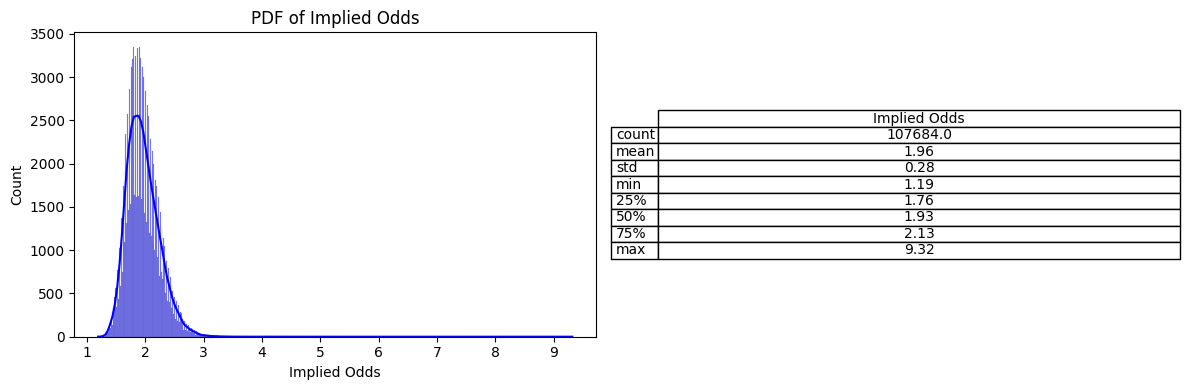

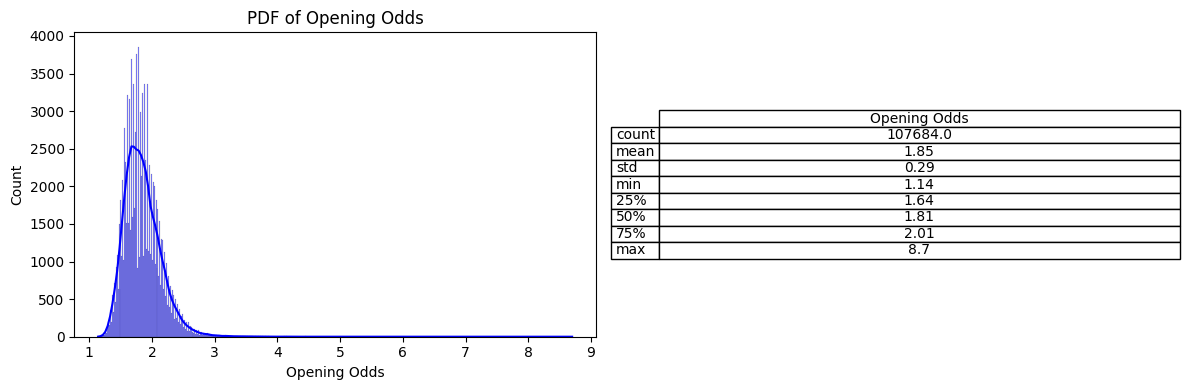

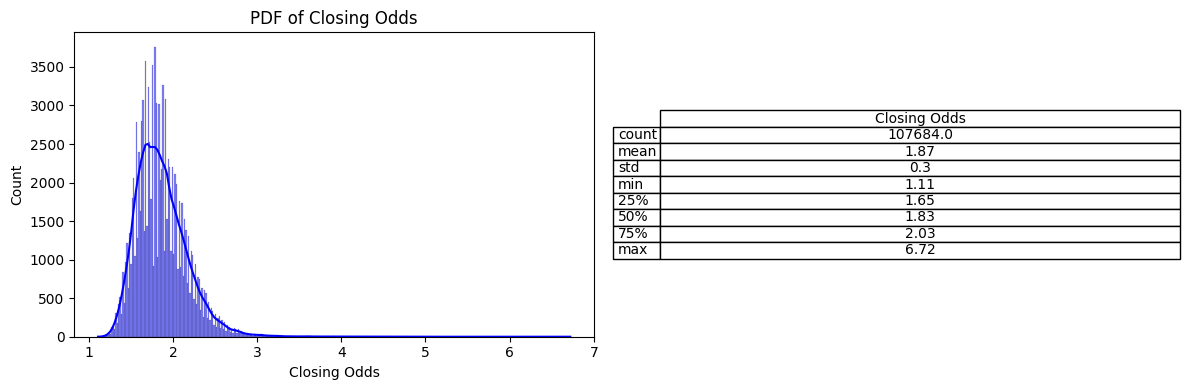

In [89]:
for column in continuous_val:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Left: distribution plot
    sns.histplot(df[column], kde=True, ax=axes[0], color="blue")
    axes[0].set_title(f"PDF of {column}")

    # Right: .describe() summary
    stats = df[column].describe().round(2)  # summary statistics
    axes[1].axis("off")  # hide axis
    axes[1].table(cellText=[[v] for v in stats.values],
                  rowLabels=stats.index,
                  colLabels=[column],
                  cellLoc="center",
                  loc="center")

    plt.tight_layout()

## Observation
- Noticed a right skewe in the distribution, which suggest outliers.Given their potential influence on regression analysis and central tendency measures, a prudent approach is to mitigate their impact. To achieve a more normal distribution, a strategic step involves removing the top 2% of the highest data points.


# Examine the proballity mass funtion of descrete variables to figure out outliers

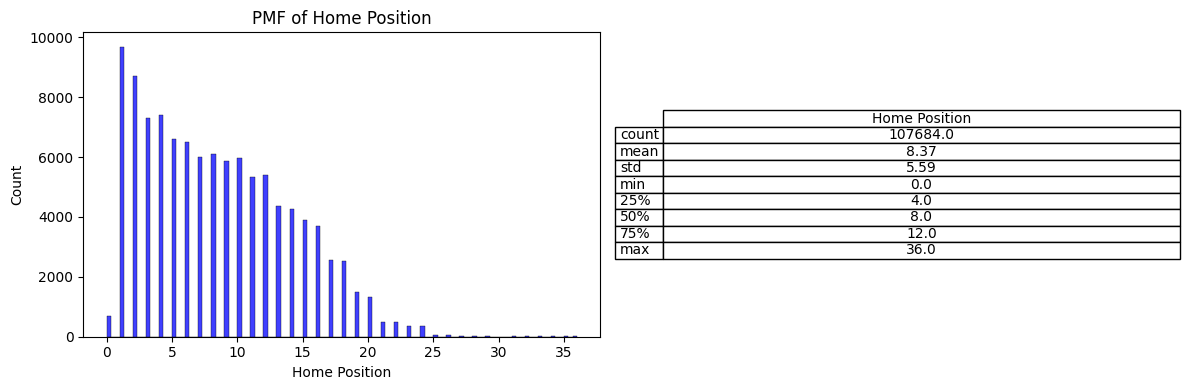

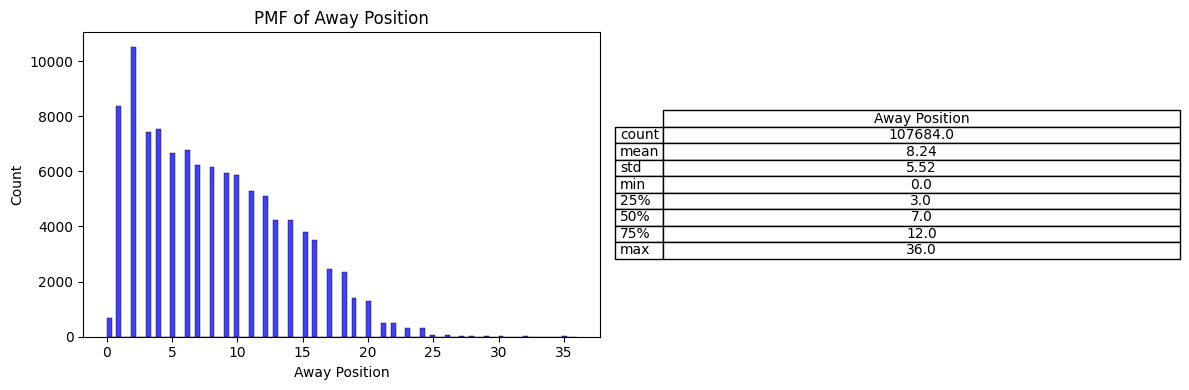

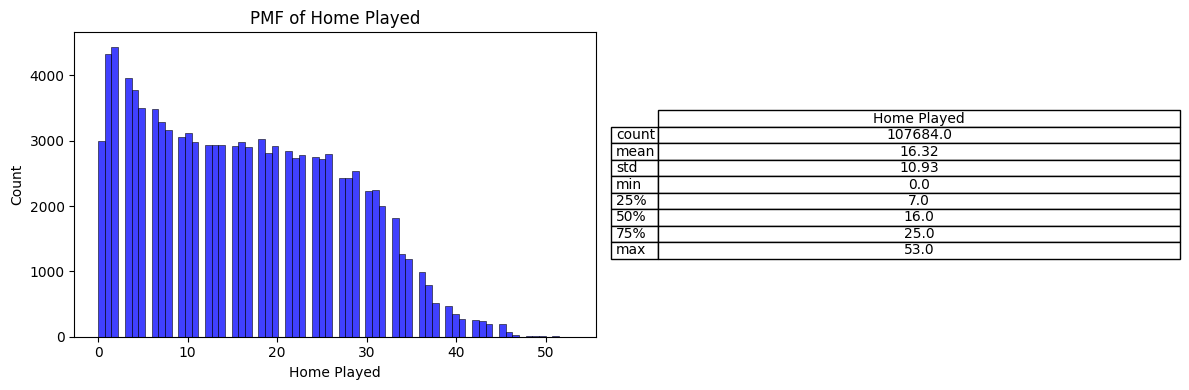

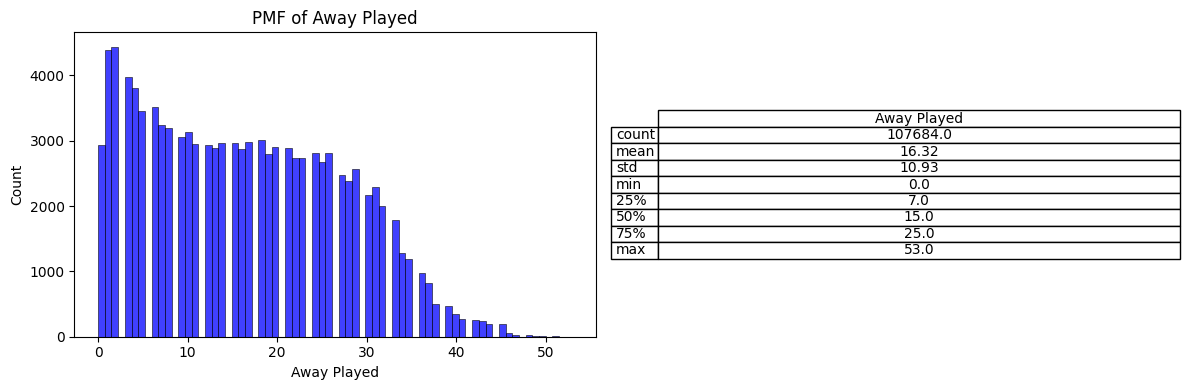

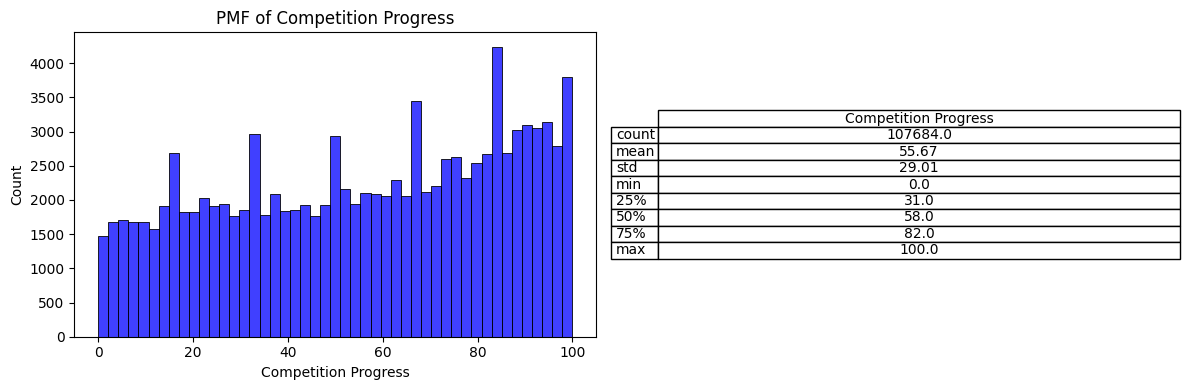

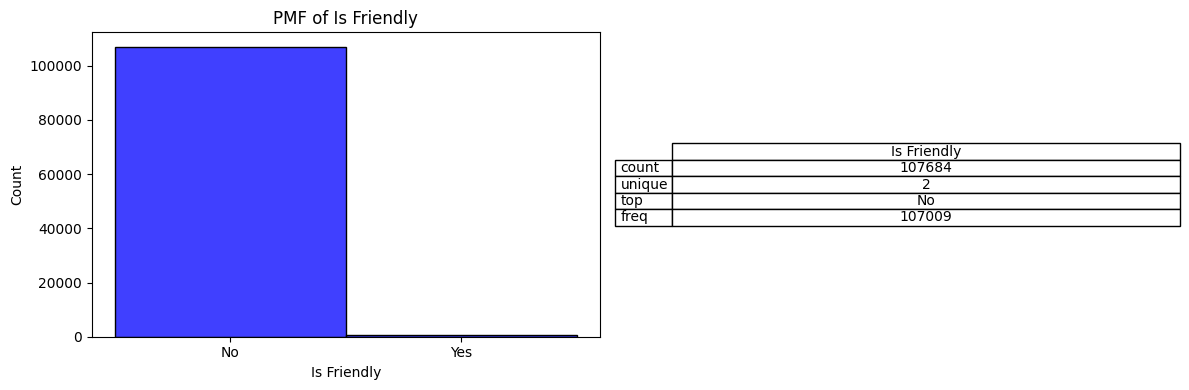

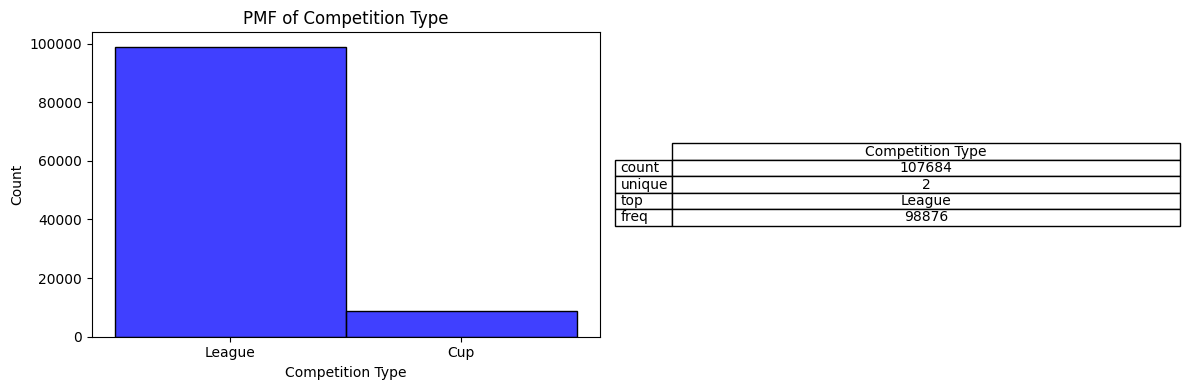

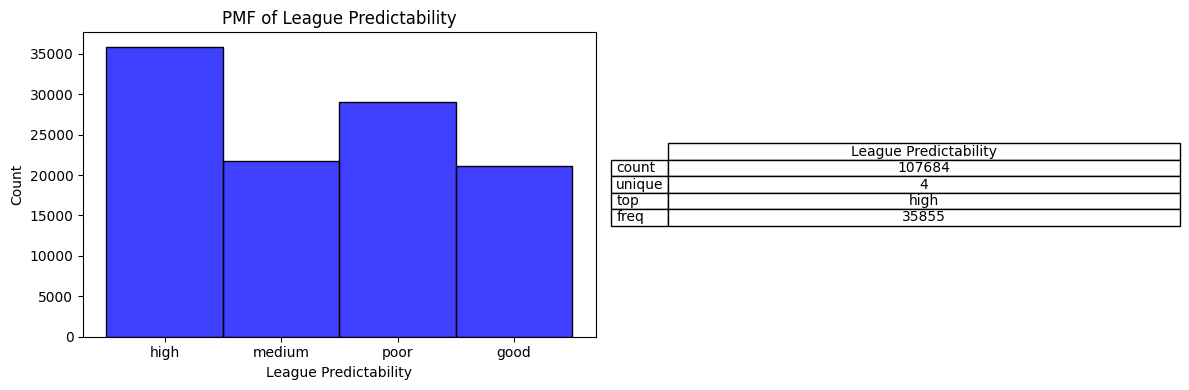

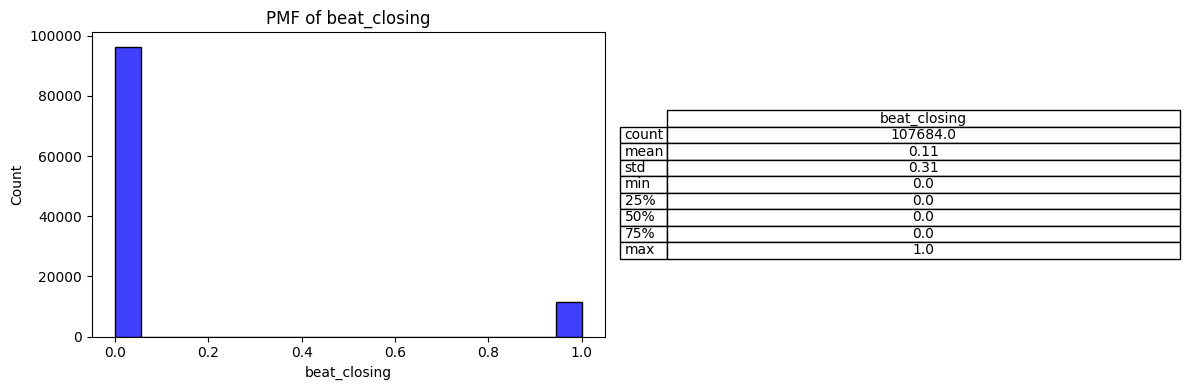

In [90]:
for column in categorical_val:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Left: distribution plot
    sns.histplot(df[column],ax=axes[0], color="blue")
    axes[0].set_title(f"PMF of {column}")

    # Right: .describe() summary
    stats = df[column].describe().round(2)  # summary statistics
    axes[1].axis("off")  # hide axis
    axes[1].table(cellText=[[v] for v in stats.values],
                  rowLabels=stats.index,
                  colLabels=[column],
                  cellLoc="center",
                  loc="center")

    plt.tight_layout()

## Observation
- There's more of league games than cup games
- There's less friendly match
- `best closing` which is the favourable condition we are looking out for is less in our dataset

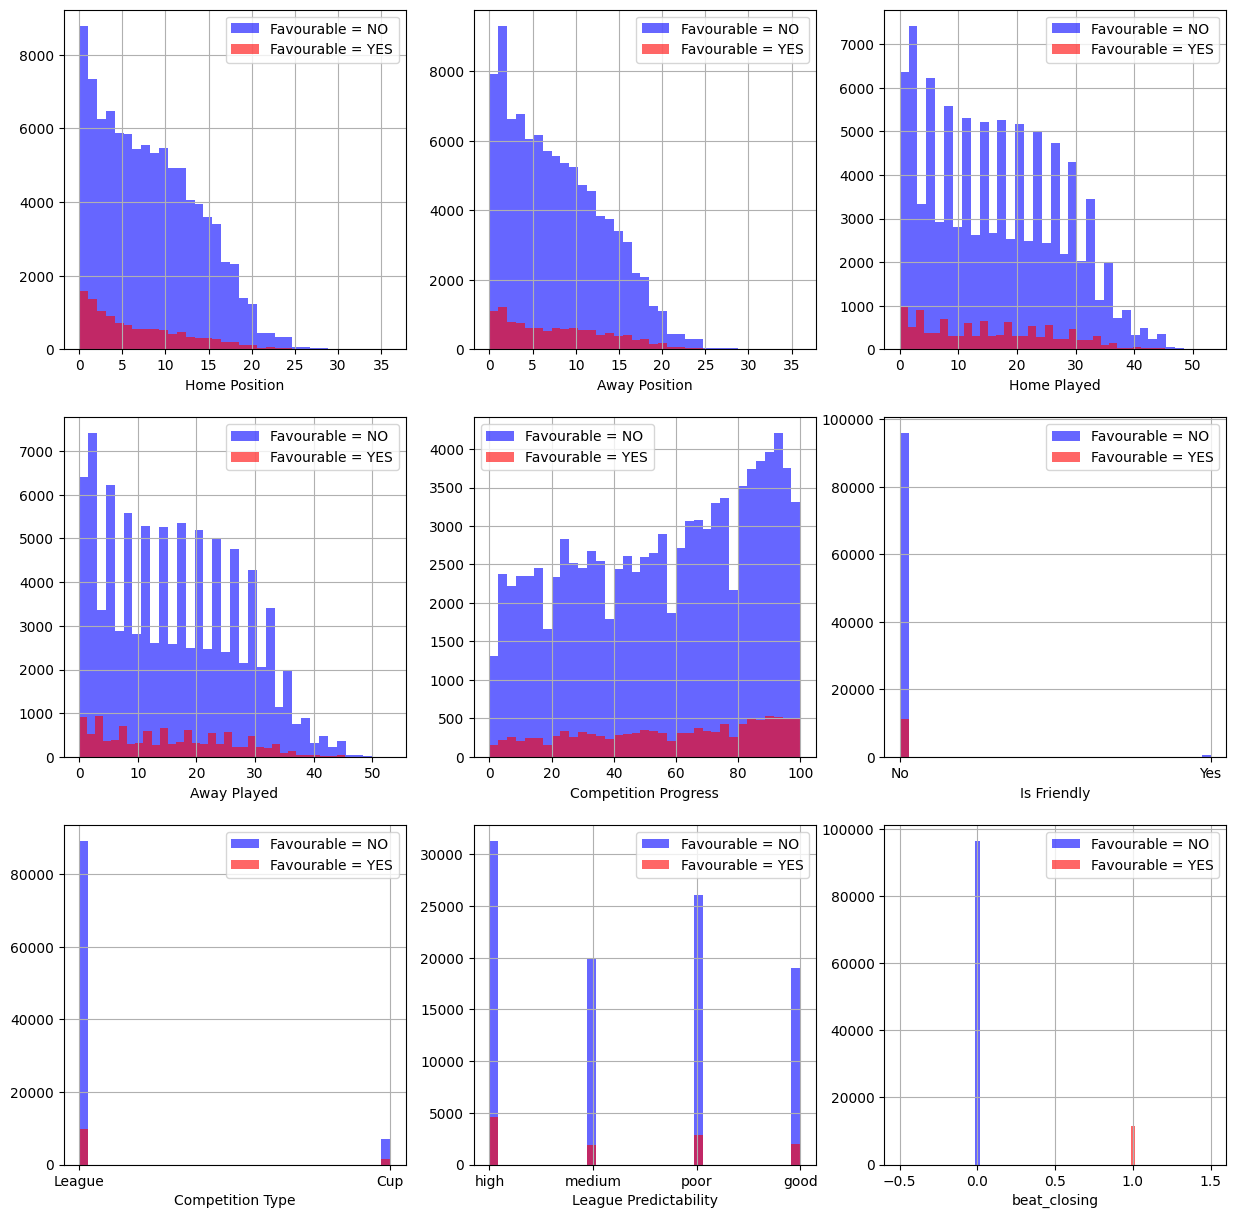

In [91]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["beat_closing"] == 0][column].hist(bins=35, color='blue', label='Favourable = NO', alpha=0.6)
    df[df["beat_closing"] == 1][column].hist(bins=35, color='red', label='Favourable = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

## Observation
- There's more favourable condition for a match that is not friendly
- More favourable condition for league games than cup games

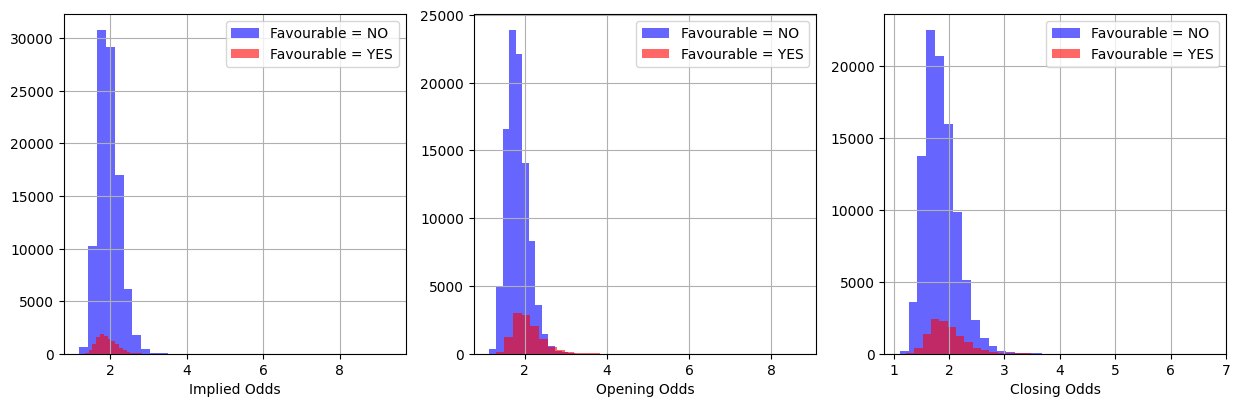

In [92]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(continuous_val, 1):
    plt.subplot(3, 3, i)
    df[df["beat_closing"] == 0][column].hist(bins=35, color='blue', label='Favourable = NO', alpha=0.6)
    df[df["beat_closing"] == 1][column].hist(bins=35, color='red', label='Favourable = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

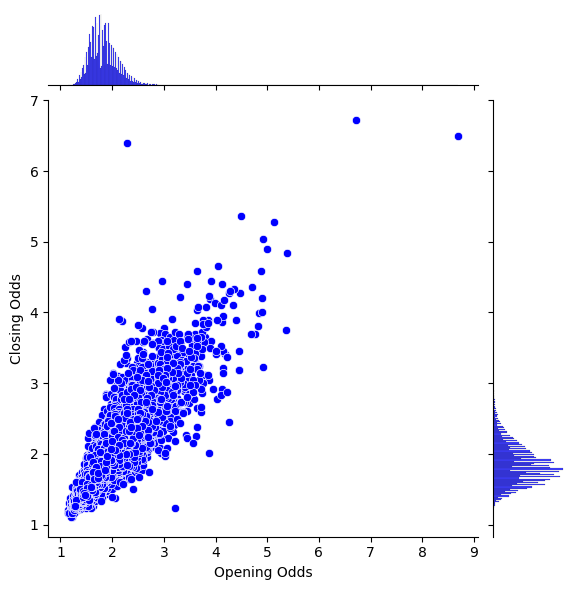

In [94]:
# examine linear relation between continuous variables and terget variables
sns.jointplot(x='Opening Odds', y='Closing Odds', data=df, kind='scatter', color='blue')

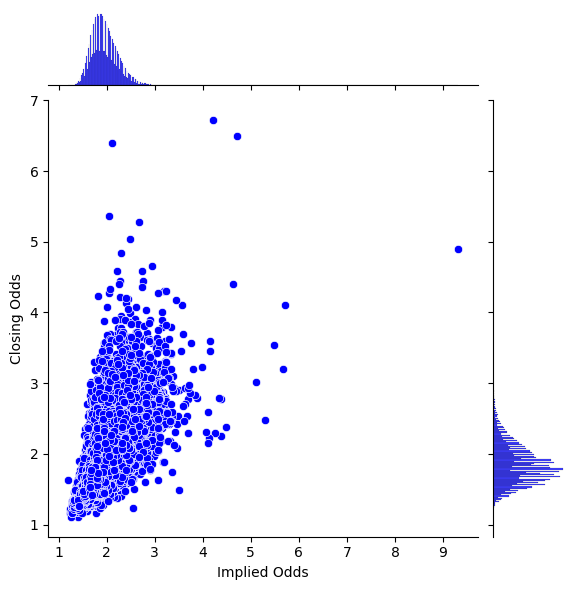

In [95]:
sns.jointplot(x='Implied Odds', y='Closing Odds', data=df, kind='scatter', color='blue')

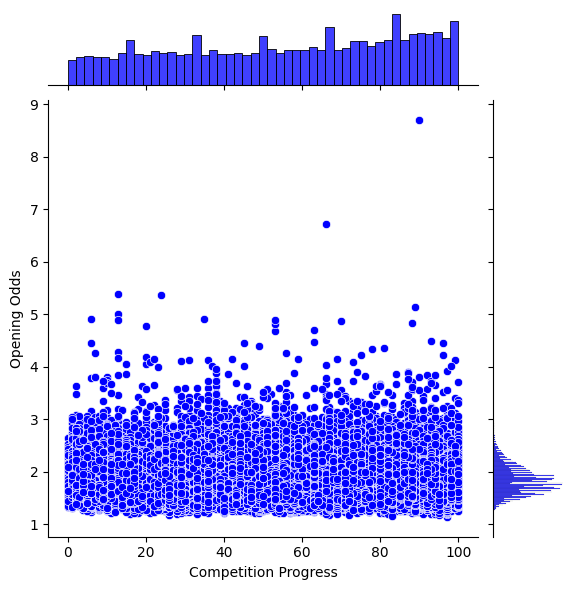

In [97]:
sns.jointplot(x='Competition Progress', y='Opening Odds', data=df, kind='scatter', color='blue')

In [98]:
# data dummification for categorical variables
df = pd.get_dummies(df, columns=categorical_val, drop_first=True)

In [100]:
df.head(20)

,Implied Odds,Opening Odds,Closing Odds,Home Position_1.0,Home Position_2.0,Home Position_3.0,Home Position_4.0,Home Position_5.0,Home Position_6.0,Home Position_7.0,...,Competition Progress_97.0,Competition Progress_98.0,Competition Progress_99.0,Competition Progress_100.0,Is Friendly_Yes,Competition Type_League,League Predictability_high,League Predictability_medium,League Predictability_poor,beat_closing_1
0,1.94,1.59,1.56,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
1,2.01,1.90,1.79,False,False,True,False,False,False,False,...,False,False,True,False,False,True,False,True,False,False
2,2.20,2.21,2.24,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,1.99,1.73,1.81,False,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
4,1.81,1.67,1.60,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
5,2.56,2.17,2.25,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
6,2.33,2.06,2.13,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
7,2.40,2.34,2.37,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
8,2.08,1.86,2.01,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
9,2.10,2.11,2.14,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [102]:
df.tail(20)

,Implied Odds,Opening Odds,Closing Odds,Home Position_1.0,Home Position_2.0,Home Position_3.0,Home Position_4.0,Home Position_5.0,Home Position_6.0,Home Position_7.0,...,Competition Progress_97.0,Competition Progress_98.0,Competition Progress_99.0,Competition Progress_100.0,Is Friendly_Yes,Competition Type_League,League Predictability_high,League Predictability_medium,League Predictability_poor,beat_closing_1
107664,2.30,2.13,2.12,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
107665,1.76,1.69,1.82,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
107666,2.14,1.88,1.88,False,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
107667,1.67,1.60,1.53,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
107668,1.81,1.60,1.56,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
107669,1.92,1.63,1.74,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
107670,1.64,1.52,1.52,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
107671,2.04,1.90,1.97,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
107672,1.83,1.65,1.65,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
107673,1.66,1.46,1.45,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [103]:
#training proceess
#extraxt the target varible closing odds
y = df['Closing Odds']
x = df.drop('Closing Odds', axis=1)
y

,Closing Odds
0,1.56
1,1.79
2,2.24
3,1.81
4,1.60
...,...
107679,2.05
107680,2.38
107681,2.27
107682,2.07


In [104]:
x

,Implied Odds,Opening Odds,Home Position_1.0,Home Position_2.0,Home Position_3.0,Home Position_4.0,Home Position_5.0,Home Position_6.0,Home Position_7.0,Home Position_8.0,...,Competition Progress_97.0,Competition Progress_98.0,Competition Progress_99.0,Competition Progress_100.0,Is Friendly_Yes,Competition Type_League,League Predictability_high,League Predictability_medium,League Predictability_poor,beat_closing_1
0,1.94,1.59,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
1,2.01,1.90,False,False,True,False,False,False,False,False,...,False,False,True,False,False,True,False,True,False,False
2,2.20,2.21,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,1.99,1.73,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,1.81,1.67,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107679,2.20,2.05,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
107680,2.32,2.36,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
107681,2.09,2.52,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
107682,2.31,1.97,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [105]:
# scale input features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-0.07015453, -0.88514479, -0.31429714, ..., -0.50358436,
        -0.60695053, -0.34373807],
       [ 0.18145553,  0.17286538, -0.31429714, ...,  1.98576462,
        -0.60695053, -0.34373807],
       [ 0.86439711,  1.23087555, -0.31429714, ...,  1.98576462,
        -0.60695053, -0.34373807],
       ...,
       [ 0.46900988,  2.28888572, -0.31429714, ...,  1.98576462,
        -0.60695053,  2.9091919 ],
       [ 1.25978435,  0.4117709 , -0.31429714, ..., -0.50358436,
        -0.60695053, -0.34373807],
       [ 1.25978435,  1.70868659, -0.31429714, ..., -0.50358436,
         1.64758073,  2.9091919 ]])

In [106]:
# partition data into test and train
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [109]:
x_train

array([[-0.35770888, -0.88514479, -0.31429714, ...,  1.98576462,
        -0.60695053, -0.34373807],
       [-0.57337464, -0.81688607, -0.31429714, ...,  1.98576462,
        -0.60695053, -0.34373807],
       [ 0.46900988,  1.29913427, -0.31429714, ..., -0.50358436,
         1.64758073,  2.9091919 ],
       ...,
       [ 2.6975561 ,  2.83495548, -0.31429714, ..., -0.50358436,
         1.64758073, -0.34373807],
       [-0.10609882, -0.33907502, -0.31429714, ..., -0.50358436,
        -0.60695053, -0.34373807],
       [ 0.14551124, -0.37320438, -0.31429714, ..., -0.50358436,
         1.64758073, -0.34373807]])

In [110]:
# train using linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [118]:
# check output of linear regression model
y_pred = model.predict(x_test)
y_pred

array([2.15746605, 1.61100717, 1.77589916, ..., 1.8880687 , 1.53126723,
       2.07025505])

In [112]:
y_test

,Closing Odds
13190,2.36
31352,1.57
63970,1.75
61621,1.91
3686,2.05
...,...
104985,1.80
5554,1.88
52829,1.79
75405,1.59


Text(0, 0.5, 'y_pred')

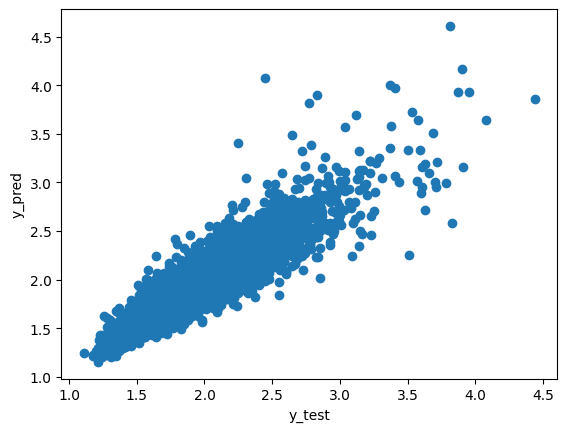

In [119]:
# plot pred_y against y_test
plt.scatter(y_test, y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')